In [78]:
import polars as pl
import re
from pathlib import Path
import textwrap as tw
import pandas as pd

import sys
sys.path.append('/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/src')

import utils

In [87]:
# res_path = Path('/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/results/mixed_dementia/nacc_multilabel/2025-10-27T12:21:53-NACC-os-sce/nacc_multilabel_output.jsonl')
# ans = pl.read_ndjson(res_path)

res_path = Path('/projectnb/vkolagrp/bellitti/adrd-foundation-model/adrd_simplified_evaluation/results/mixed_dementia/nacc_multilabel/2025-10-27T12:21:53-NACC-os-sce/nacc_multilabel_output_extracted_answers_last.parquet')
df = pl.read_parquet(res_path)

In [107]:
with pl.Config(tbl_rows=10, fmt_str_lengths=5000):
    display(df.filter(
        pl.col('extracted') == ''
    ).sample().select('generated_text','extracted','prediction')
    )

generated_text,extracted,prediction
str,str,str
"""To determine the contributing causes of the patient's cognitive decline, considering the findings described in the patient's evaluation, we will analyze each provided option and determine which is most likely or applicable: 1. **Psychiatric Conditions (depression, bipolar, schizophrenia, anxiety, PTSD)**: - According to the provided information, his spouse reported no behavioral or psychological symptoms of dementia. Hence, no history of depression, bipolar, schizophrenia, or anxiety indications were noted. 2. **Alzheimer's Disease**: - His cognitive score of 28 on the MMSE is within normal limits, excluding mild cognitive impairment. There are no clinical signs such as a history of dementia, memory loss, neuropsychological deficits, or pathognomonic symptoms of Alzheimer's. 3. **Other Dementia Etiology, including MSA, Down's syndrome, Huntington's, Epilepsy, Neoplasm, and any etiology not appearing in another option**: - Since there were no other specific cognitive deficits, he did not suffer from MSA, Down's syndrome, Huntington's, epilepsy, neoplasm, etc., indicating that none of these conditions apply. 4. **Lewy Body Disease (including Dementia with Lewy Bodies and Parkinson's disease)**: - No examination or neurologic symptoms indicated Parkinson's disease or features associated with Dementia with Lewy Bodies. 5. **Frontotemporal Dementia (FTLD; including CBD, PSP, with/without ALS)**: - None of the neuropsychological tests suggested any frontotemporal dementia patterns or impairment consistent with cerebral small vessel disease, such as frontotemporal degeneration. 6. **Vascular Dementia**: - Given the Hachinski score of 1, a low likelihood of vascular cognitive impairment, clinical presence, and absence of any vascular signs in the physical exam. 7. **Systemic and External Factors (infectious, metabolic, substance abuse, etc.)**: - The patient has no history of infectious disease, metabolic issues, or substance abuse as reasons for cognitive decline. 8. **Not applicable, no cognitive impairment**: - Despite mild impairment evident from a few abnormal test scores on MMSE, mild cognitive impairment is likely given the test scores and within the normal range for his functional activities. Based on the clinical criteria provided in the context, the only possible overlapping and confirmed are: \boxed{H. Systemic and External Factors (infectious, metabolic, substance abuse, etc.).}""","""""","""H"""


In [15]:
from scipy.special import gamma
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [32]:
def rel_error(N):
    return np.sqrt(1 - 2/(N-1) * ( gamma(N/2) / gamma( (N-1)/2 ) )**2 )

In [55]:
x = np.geomspace(2,70,10)
y = rel_error(x)

In [56]:
from matplotlib.ticker import FormatStrFormatter



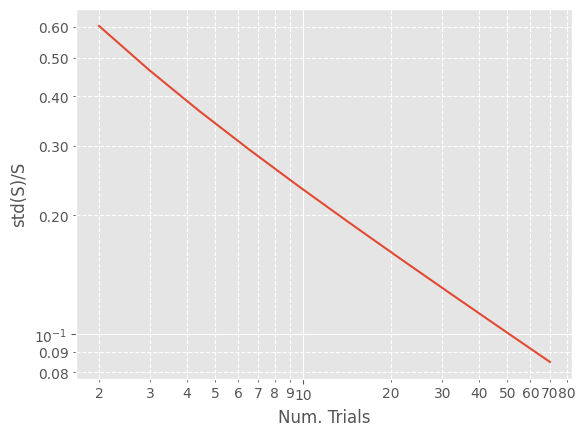

In [58]:
plt.loglog(x,y)
plt.xlabel('Num. Trials')
plt.ylabel('std(S)/S')
plt.grid(visible=True, which='minor', color='white', linestyle='--')

ax = plt.gca()
ax.set_yscale('log')
plt.tick_params(axis='y', which='minor')
ax.yaxis.set_minor_formatter(FormatStrFormatter("%.2f"))
ax.xaxis.set_minor_formatter(FormatStrFormatter("%d"))
ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
plt.show()
